In [33]:
import sqlite3
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import seaborn as sns
# Connect to the database
conn = sqlite3.connect("../database.db")

# Read data into a DataFrame
df = pd.read_sql_query("SELECT * FROM activations", conn)

# Close the connection
conn.close()

In [34]:
# Original 
experiment_no = "results/exp_20250415_143930"
# Proposed
# experiment_no = "results/exp_20250415_134450"
# experiment_no = "results/exp_20250417_112320"
#warm container
# experiment_no = "results/exp_20250402_173638"

filtered_df = df[df["experiment_id"] == experiment_no]

functions = pd.read_csv('../dataset/functions.csv')

function_df = functions.set_index('id').to_dict(orient='index')
# filtered_df = filtered_df[filtered_df['activation_id'] != '206d5f32fa864835ad5f32fa86083544']
image_df = functions.set_index('docker').to_dict(orient='index')

In [35]:
ml_models = {}
images_names = []
image_gpu_time = {}
check_test = {}
max_value = 0
overall_data = []
for _, row in filtered_df.iterrows():
    json_object = json.loads(row['json_data'])
    measurement = json_object.get('response', {}).get('result', {}).get('measurement', {})
    image_load_start = measurement.get('image_load_start', measurement.get('input_load_start'))
    image_load_end = measurement.get('image_load_start', measurement.get('input_load_end'))
    temp = {}
    start = json_object['start']
    end = json_object['end']
    init_time = 0
    for annotation in json_object['annotations']:
        if annotation['key'] == 'initTime':
            init_time = annotation['value']
            break

    for annotation in json_object['annotations']:
        if annotation['key'] == 'path':
            path = annotation['value']
            break
    images_names.append(path)

    lib_load_start = json_object['response']['result']['measurement']['lib_load_start']
    lib_load_end = (json_object['response']['result']['measurement']['lib_load_end'] - lib_load_start + init_time)/1000
    model_load_start = (json_object['response']['result']['measurement']['model_load_start'] - lib_load_start + init_time)/1000
    model_load_end = (json_object['response']['result']['measurement']['model_load_end'] - lib_load_start + init_time)/1000
    image_load_start = (image_load_start - lib_load_start + init_time)/1000
    image_load_end = (image_load_end - lib_load_start + init_time)/1000
    gpu_transfer_start = (json_object['response']['result']['measurement']['gpu_transfer_start'] - lib_load_start + init_time)/1000
    gpu_transfer_end = (json_object['response']['result']['measurement']['gpu_transfer_end'] - lib_load_start + init_time)/1000
    preprocess_start = (json_object['response']['result']['measurement']['preprocess_start'] - lib_load_start + init_time)/1000
    preprocess_end = (json_object['response']['result']['measurement']['preprocess_end'] - lib_load_start + init_time)/1000
    inference_start = (json_object['response']['result']['measurement']['inference_start'] - lib_load_start + init_time)/1000
    inference_end = (json_object['response']['result']['measurement']['inference_end'] - lib_load_start + init_time)/1000
    output_start = (json_object['response']['result']['measurement']['output_start'] - lib_load_start + init_time)/1000
    output_end = (json_object['response']['result']['measurement']['output_end'] - lib_load_start + init_time)/1000
    lib_load_start = init_time/1000
    init_time = init_time/1000
    

    temp['Container Initialization'] = (0,init_time)
    temp['Library Initialization'] = (init_time, lib_load_end)
    temp['Input Prep'] = (lib_load_end, image_load_end)
    temp['Model Load'] = (image_load_end, model_load_end)
    temp['GPU Transfer'] = (model_load_end, gpu_transfer_end)
    temp['Inference'] = (gpu_transfer_end, inference_end)
    temp['Output'] = (inference_end, output_end)
    ml_models[json_object['name']] = temp
    image_gpu_time[json_object['name']] = model_load_start
    # temp['Keep alive'] = (output_end,output_end+600)

    max_value = max(max_value, output_end)
    overall_data.append(temp)
    
   
   

In [36]:
 overall_data

[{'Container Initialization': (0, 1.424),
  'Library Initialization': (1.424, 2.663),
  'Input Prep': (2.663, 2.823),
  'Model Load': (2.823, 3.403),
  'GPU Transfer': (3.403, 3.713),
  'Inference': (3.713, 3.862),
  'Output': (3.862, 3.872)},
 {'Container Initialization': (0, 1.403),
  'Library Initialization': (1.403, 2.614),
  'Input Prep': (2.614, 2.81),
  'Model Load': (2.81, 3.194),
  'GPU Transfer': (3.194, 3.494),
  'Inference': (3.494, 3.711),
  'Output': (3.711, 3.721)},
 {'Container Initialization': (0, 1.385),
  'Library Initialization': (1.385, 2.582),
  'Input Prep': (2.582, 2.791),
  'Model Load': (2.791, 3.82),
  'GPU Transfer': (3.82, 4.05),
  'Inference': (4.05, 4.302),
  'Output': (4.302, 4.311)},
 {'Container Initialization': (0, 1.395),
  'Library Initialization': (1.395, 2.603),
  'Input Prep': (2.603, 2.781),
  'Model Load': (2.781, 2.916),
  'GPU Transfer': (2.916, 3.225),
  'Inference': (3.225, 3.49),
  'Output': (3.49, 3.501)},
 {'Container Initialization': (0

In [37]:
# Convert data into a DataFrame
cf = pd.DataFrame(overall_data)
# Correct the subtraction order: subtract the 1st value from the 2nd value
execution_times_correct = {
    phase: cf[phase].apply(lambda x: x[1] - x[0]) for phase in cf.columns
}

# Calculate the average time for each phase across all models
average_times_per_phase = {
    phase: execution_times_correct[phase].mean() for phase in execution_times_correct
}

# Display the average times for each phase
print("Average Execution Times per Phase (in seconds):")
for phase, time in average_times_per_phase.items():
    print(f"{phase}: {time:.3f} seconds")

Average Execution Times per Phase (in seconds):
Container Initialization: 1.447 seconds
Library Initialization: 1.257 seconds
Input Prep: 0.167 seconds
Model Load: 0.735 seconds
GPU Transfer: 0.310 seconds
Inference: 0.288 seconds
Output: 0.007 seconds


In [38]:
gpu_stages = {"Model Load", "GPU Transfer", "Inference", "Output","Keep-Alive"}
stage_colors = {
    "Container Initialization": "#99ccff",   # Medium soft blue
    "Library Initialization": "#b7d7b0",     # Light sage green
    "Input Prep": "#ffe599",       # Light amber
    "Model Load": "#d6b5dd",       # Dusty lavender
    "GPU Transfer": "#f4b6b6",    # Muted pink-red
    "Inference": "#b7d2f0",        # Softer blue
    "Output": "#d9d9d9",           # Soft gray
    "Keep-Alive": "#fbe6b7"        # Warm cream
}


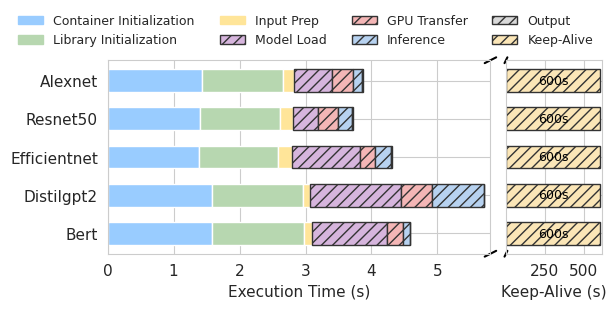

In [41]:


# Apply improved styling for academic figures
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
has_hatch = True
# Data configuration
KEEP_ALIVE_TIME = 600  # seconds
MODEL_NAMES_SELECTED = ['alexnet', 'resnet50', 'efficientnet', 'distilgpt2', 'bert']
# MODEL_NAMES_SELECTED = ['alexnet', 'resnet50', 'efficientnet', 'distilgpt2', 'bert','googlenet','inception']
NUM_MODELS = len(MODEL_NAMES_SELECTED)
INDICES = np.arange(NUM_MODELS)
BAR_HEIGHT = 0.6

# Calculate execution metrics
# Calculate execution metrics (corrected)
execution_ends = np.array([max(end for (_start, end) in ml_models[model].values())
                        for model in MODEL_NAMES_SELECTED])
keep_alive_ends = execution_ends + KEEP_ALIVE_TIME


# Create figure with constrained layout
fig, (ax_main, ax_keepalive) = plt.subplots(
    1, 2,
    figsize=(6, 2.5),
    sharey=True,
    gridspec_kw={
        'width_ratios': [4, 1],
        'wspace': 0.01
    },
    layout='constrained'
)

# Plot main execution stages
for model_idx, model_name in enumerate(MODEL_NAMES_SELECTED):
    stages = ml_models[model_name]
    for stage_name, (start, end) in stages.items():
        duration = end - start
        color = stage_colors.get(stage_name, 'gray')

        # Use hatches for GPU-utilizing stages
        hatch = '///' if stage_name in gpu_stages else None
        edgecolor = '#333333' if hatch else None

        ax_main.barh(
            model_idx, duration, BAR_HEIGHT,
            left=start, color=color,
            hatch=hatch, edgecolor=edgecolor
        )

# Plot keep-alive periods
for model_idx, (ka_start, ka_end) in enumerate(zip(execution_ends, keep_alive_ends)):
    ax_keepalive.barh(
        model_idx, KEEP_ALIVE_TIME, BAR_HEIGHT,
        left=ka_start, color=stage_colors["Keep-Alive"],
        edgecolor='#333333',
        **({'hatch': '///'} if has_hatch else {})
    )
    # Centered text annotation
    ax_keepalive.text(
        ka_start + KEEP_ALIVE_TIME/2, model_idx,
        f"{KEEP_ALIVE_TIME}s",
        va='center', ha='center',
        fontsize=9, color='black'
    )

# Axis configuration
ax_main.set_xlim(0, max_value+0.1)
ax_keepalive.set_xlim(execution_ends.min() - 0.5, keep_alive_ends.max() + 10)
ax_main.set_xlabel('Execution Time (s)', fontweight='normal')
ax_keepalive.set_xlabel('Keep-Alive (s)', fontweight='normal')
ax_main.set_yticks(INDICES)
ax_main.set_yticklabels([name.capitalize() for name in MODEL_NAMES_SELECTED])
ax_main.invert_yaxis()  # Top-down model ordering

# Add axis break indicators
def add_axis_break(ax, position='right'):
    d = 0.015  # Diagonal break size
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    if position == 'right':
        ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    else:
        ax.plot((-d, +d), (-d, +d), **kwargs)
        ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)

add_axis_break(ax_main, 'right')
add_axis_break(ax_keepalive, 'left')

# Create enhanced legend
legend_handles = []

for stage_name, color in stage_colors.items():
    if stage_name == "Keep-Alive": continue  # Handled separately

    if stage_name in gpu_stages:
        legend_handles.append(
            Rectangle((0,0), 1, 1,
                      facecolor=color, edgecolor='#333333',
                      hatch='///', label=stage_name)
        )
    else:
        legend_handles.append(
            mpatches.Patch(color=color, label=stage_name)
        )

# Add keep-alive legend entry
legend_handles.append(
    Rectangle((0,0), 1, 1,
              facecolor=stage_colors["Keep-Alive"],
              edgecolor='#333333',
              label='Keep-Alive',hatch='///')
)

fig.legend(
    handles=legend_handles,
    loc='outside upper center',
    ncol=4,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, 1.2)
)

# Final adjustments
# ax_main.grid(True, axis='x', linestyle=':', alpha=0.7)
# ax_keepalive.grid(True, axis='x', linestyle=':', alpha=0.7)

# plt.savefig("model_timelines.pdf", bbox_inches='tight')
plt.savefig("model_timelines_original.jpg", bbox_inches='tight', dpi=300)
plt.show()

In [8]:
def extract_model_names(model_list):
    return [model.split('/')[-1] for model in model_list]

def models_values(exp_no,image_gpu_time):
    df = pd.read_csv(f'../{exp_no}/gpu_usage.csv')
    df['time_since_start_sec'] = (df['Timestamp'] - df['Timestamp'].iloc[0]) / 1000
    df['Model'] = df['ImageName'].str.extract(r'ml-inference:([a-z0-9]+)', expand=False)
    df['gpu_delay'] = df['Model'].map(image_gpu_time)
    df['time_since_start_sec'] = df['time_since_start_sec'] + df['gpu_delay']
    grouped_final = df.groupby('Model')
    models_real_final = {}
    for name, group in grouped_final:
        models_real_final[name] = {
            'time': group['time_since_start_sec'].tolist(),
            'memory': group['GPU_Memory_MB'].tolist()
        }
    return models_real_final
    



In [133]:
models_names = extract_model_names(images_names)
models = models_values(experiment_no,image_gpu_time)

In [134]:
filtered_data = {k: data[k] for k in selected_keys if k in data}

NameError: name 'selected_keys' is not defined

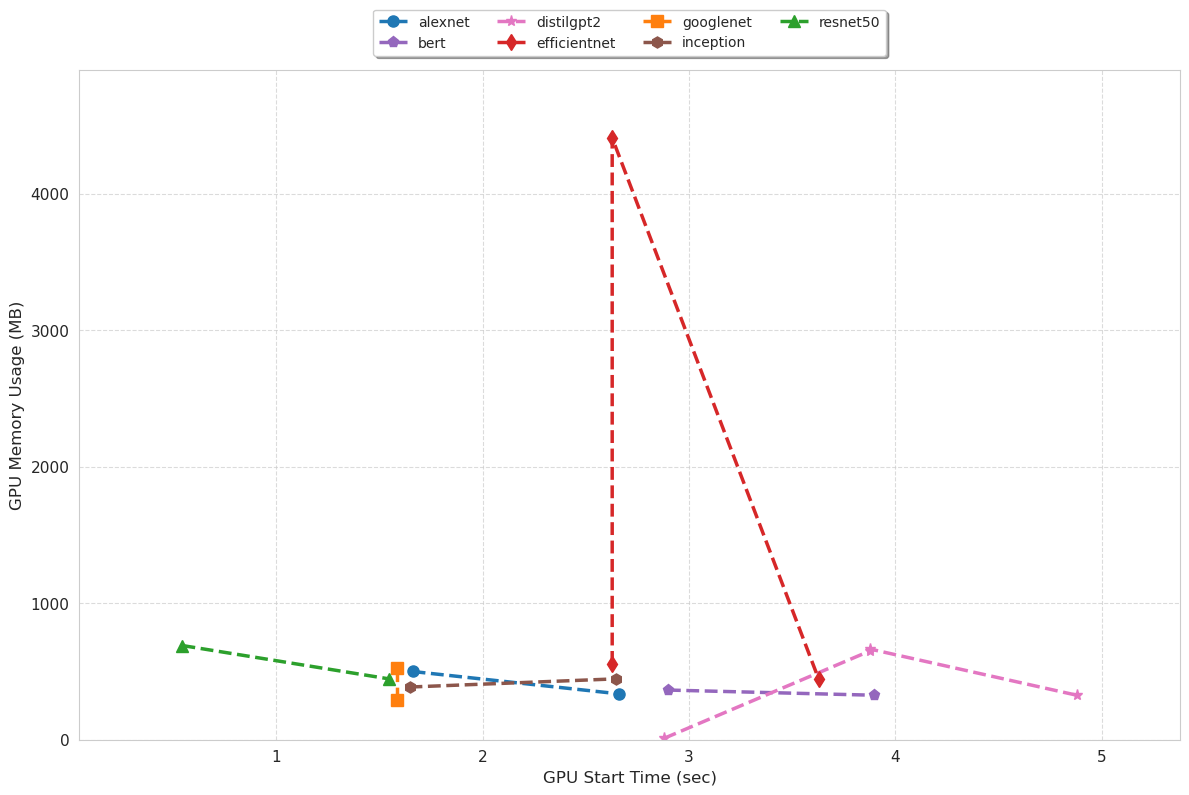

In [185]:
# Define a better color palette with higher contrast
colors = {
    'alexnet': '#1f77b4',      # blue
    'googlenet': '#ff7f0e',    # orange
    'resnet50': '#2ca02c',     # green
    'efficientnet': '#d62728', # red
    'bert': '#9467bd',         # purple
    'inception': '#8c564b',    # brown
    'distilgpt2': '#e377c2'    # pink
}

# Define line styles for better differentiation
line_styles = {
    'alexnet': '--',
    'googlenet': '--',
    'resnet50': '--',
    'efficientnet': '--',
    'bert': '--',
    'inception': '--',
    'distilgpt2': '--'
}

# Define marker styles
marker_styles = {
    'alexnet': 'o',
    'googlenet': 's',
    'resnet50': '^',
    'efficientnet': 'd',
    'bert': 'p',
    'inception': 'h',
    'distilgpt2': '*'
}

# Dynamic calculation for limits
all_times = np.concatenate([data['time'] for data in models.values()])
all_memory = np.concatenate([data['memory'] for data in models.values()])
x_min, x_max = all_times.min() - 0.5, all_times.max() + 0.5
y_min, y_max = 0, all_memory.max() + 500

# Create the plot
plt.figure(figsize=(12, 8))

for model, data in models.items():
    plt.plot(
        data['time'],
        data['memory'],
        label=model,
        color=colors[model],
        linestyle=line_styles[model],
        marker=marker_styles[model],
        markersize=8,
        linewidth=2.5
    )

# Grid and labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('GPU Start Time (sec)', fontsize=12)
plt.ylabel('GPU Memory Usage (MB)', fontsize=12)
# plt.title('GPU Memory Consumption Over Time by Neural Network Architecture', fontsize=14, fontweight='bold')

# Dynamic legends with all models
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4, fontsize=10, frameon=True, fancybox=True, shadow=True)

# Dynamically set axis limits
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

# Improved tick density dynamically calculated
# plt.xticks(np.arange(x_min, x_max, 0.5), fontsize=10)
# plt.yticks(np.arange(y_min, y_max, 500), fontsize=10)

plt.tight_layout()
plt.show()

In [136]:
dfs = {model: pd.DataFrame(records) for model, records in models.items()}

In [137]:
time_ranges = {
    model: {
        'time': df['time'].max() - df['time'].min(),
        'memory': df['memory'].mean()
    }
    for model, df in dfs.items()
}
time_ranges

{'alexnet': {'time': 1.0, 'memory': 418.0},
 'bert': {'time': 1.0, 'memory': 345.0},
 'distilgpt2': {'time': 1.9999999999999996, 'memory': 413.0},
 'efficientnet': {'time': 1.0, 'memory': 1804.0},
 'googlenet': {'time': 0.0, 'memory': 408.0},
 'inception': {'time': 1.0, 'memory': 416.0},
 'resnet50': {'time': 1.0, 'memory': 568.0}}

In [138]:
dfs['alexnet']['time'].max()

2.661

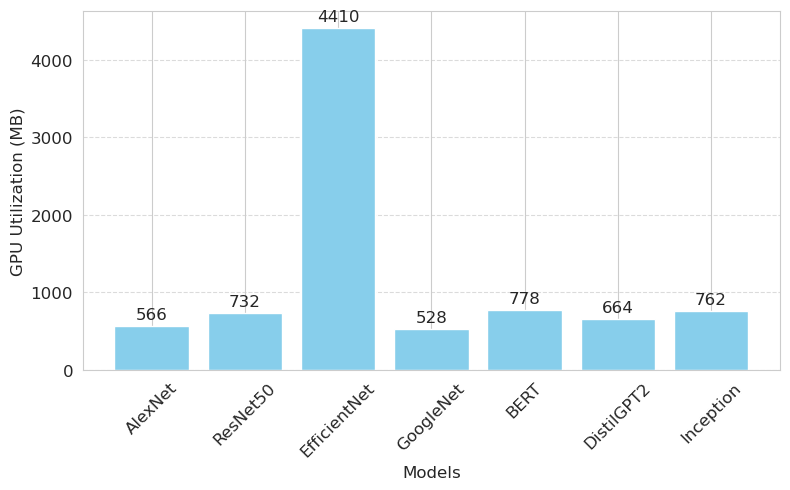

In [21]:
import matplotlib.pyplot as plt

# Model names and their corresponding GPU utilization values
models = ['AlexNet', 'ResNet50', 'EfficientNet', 'GoogleNet', 'BERT', 'DistilGPT2', 'Inception']
gpu_utilization = [566, 732, 4410, 528, 778, 664, 762]

# Plotting again with font size adjustments
plt.figure(figsize=(8, 5))
bars = plt.bar(models, gpu_utilization, color='skyblue')
# plt.title('GPU Utilization by Model Function', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylabel('GPU Utilization (MB)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, int(yval), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("gpu_utilization.jpg", bbox_inches='tight', dpi=300)
plt.show()


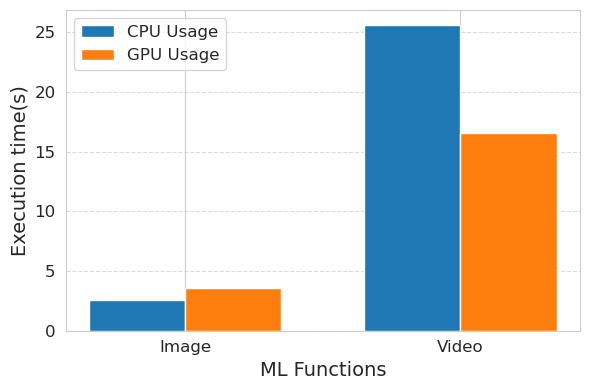

In [27]:
import matplotlib.pyplot as plt

# Data
tasks = ['Image', 'Video']
cpu_usage = [2.584, 25.5792]
gpu_usage = [3.591, 16.595]

# Plotting
x = range(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar([p - width/2 for p in x], cpu_usage, width, label='CPU Usage')
bars2 = ax.bar([p + width/2 for p in x], gpu_usage, width, label='GPU Usage')

# Labels and formatting
ax.set_ylabel('Execution time(s)', fontsize=14)
# ax.set_title('CPU vs GPU Usage for Image and Video Processing', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('ML Functions', fontsize=12)
# Set font sizes for axis labels
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)

plt.tight_layout()
plt.savefig("cpu_gpu_usages.jpg", bbox_inches='tight', dpi=300)
plt.show()
